In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.externals.array_api_compat.dask.array import cumulative_sum


In [105]:
## part to select rows to add to final parquet file
source_df = pd.read_parquet(Path.cwd() / 'parquet' / 'k0_search_2')
target_df = pd.read_parquet(Path.cwd() / 'parquet' / 'k0_search')

filtered_rows = source_df.iloc[4:8]
filtered_rows_2 = target_df.iloc[-2:]

combined_df = pd.concat([filtered_rows_2, filtered_rows], ignore_index=True)
combined_df.to_parquet(Path.cwd() / 'parquet' / 'k0_search_final.parquet', index=False)
combined_df.drop(columns=["steps_and_losses"],inplace=True)
combined_df
#####################

,best_x,best_loss,steps,corr_loss,seed,time_elapsed,algorithm,iterations,n_part,experimental_data_path,eval_metric,best_per_epoch,best_k0_per_epoch,max_iterations
0,0.000325,0.005454,"[0.0004013919564039609, 0.00040059358363933915...","[0.016876753721977663, 0.015134532279970588, 0...",1752316254,14697.868351,CMA,100,4096,Rigidity_Proton_AMS-02_PRL1272021271102_201809...,mean_relative_error,"[0.011747418567509741, 0.007427609771802457, 0...","[0.0003662163514303274, 0.000325, 0.0003249995...",100.0
1,0.000300,0.004983,"[0.0004013919564039609, 0.0004159072694614891,...","[0.016980751954507368, 0.01683323169516632, 0....",1752316254,14617.824463,PSO,100,4096,Rigidity_Proton_AMS-02_PRL1272021271102_201809...,mean_relative_error,"[0.011787485959473445, 0.005930384741790627, 0...","[0.0003644662012381252, 0.00030452166341314216...",100.0
2,0.000321,0.004876,"[0.0004013919564039609, 0.00041914748883602334...","[0.01732935782039478, 0.018855879680070634, 0....",1752328118,11940.121544,DE,100,4096,Rigidity_Proton_AMS-02_PRL1272021271102_201809...,mean_relative_error,"[0.011390062547865397, 0.005902629657379217, 0...","[0.0003677752595194169, 0.00032500939882173043...",100.0
3,0.000318,0.004674,"[0.0004013919564039609, 0.0004376121451622357,...","[0.017416639477101103, 0.02110627218867437, 0....",1752328118,11951.712802,TwoPointsDE,100,4096,Rigidity_Proton_AMS-02_PRL1272021271102_201809...,mean_relative_error,"[0.01012340717508927, 0.008424937000486105, 0....","[0.00036252930012963306, 0.0003129244764484631...",100.0
4,0.000316,0.004599,"[0.0004013919564039609, 0.00041603796249901936...","[0.017372512611677132, 0.018172127139805448, 0...",1752328118,11954.144675,TBPSA,100,4096,Rigidity_Proton_AMS-02_PRL1272021271102_201809...,mean_relative_error,"[0.01167702464315172, 0.0057585585405908555, 0...","[0.000369503651860977, 0.00032387403159725767,...",100.0
5,0.000320,0.005307,"[0.0004013919564039609, 0.00042547068142442416...","[0.01709329266339556, 0.019722607394826824, 0....",1752328118,11868.676299,RandomSearch,100,4096,Rigidity_Proton_AMS-02_PRL1272021271102_201809...,mean_relative_error,"[0.01193629882718261, 0.006715621511559115, 0....","[0.0003643191615543976, 0.0002955623639243559,...",100.0


In [106]:


def extract_period(experimental_data_path):
    match = re.search(r"_(\d{8})_(\d{8})", experimental_data_path)
    if match:
        start_date = match.group(1)
        end_date = match.group(2)
        period_label = f"{start_date}_{end_date}"
        return period_label
    else:
        print(f"No period found in: {experimental_data_path}")
        return "unknown"

def plot_k0_comparison(df):
    # Estrai periodo dal path se non esiste già
    if "periodo" not in df.columns:
        df["periodo"] = df["experimental_data_path"].apply(extract_period)

    plt.figure(figsize=(14, 6))
    sns.barplot(
        data=df,
        x="periodo",
        y="best_x",
        hue="algorithm",
        palette="tab10"
    )

    plt.title("Confronto dei valori ottimali di $k_0$ per algoritmo e periodo")
    plt.xlabel("Periodo")
    plt.ylabel(r"Valore ottimale di $k_0$")
    plt.xticks(rotation=45)
    plt.legend(title="Algoritmo")
    plt.tight_layout()
    plt.show()



In [120]:
parquet_path = Path.cwd() / 'parquet' / 'k0_search_v2'
df = pd.read_parquet(parquet_path)
df.head(100)

,best_x,best_loss,steps,corr_loss,seed,time_elapsed,algorithm,iterations,n_part,experimental_data_path,eval_metric,best_per_epoch,best_k0_per_epoch,max_iterations
0,[0.0003624521713860098],0.015122,"[[0.0003189034129276761], [0.00031890341292767...",[],1752411893,-44.675983,Fuzzy-PSO,4,0,,mean_relative_error,"[0.015122145335528773, 0.015122145335528773, 0...","[[0.0003624521713860098], [0.00039246082356011...",2


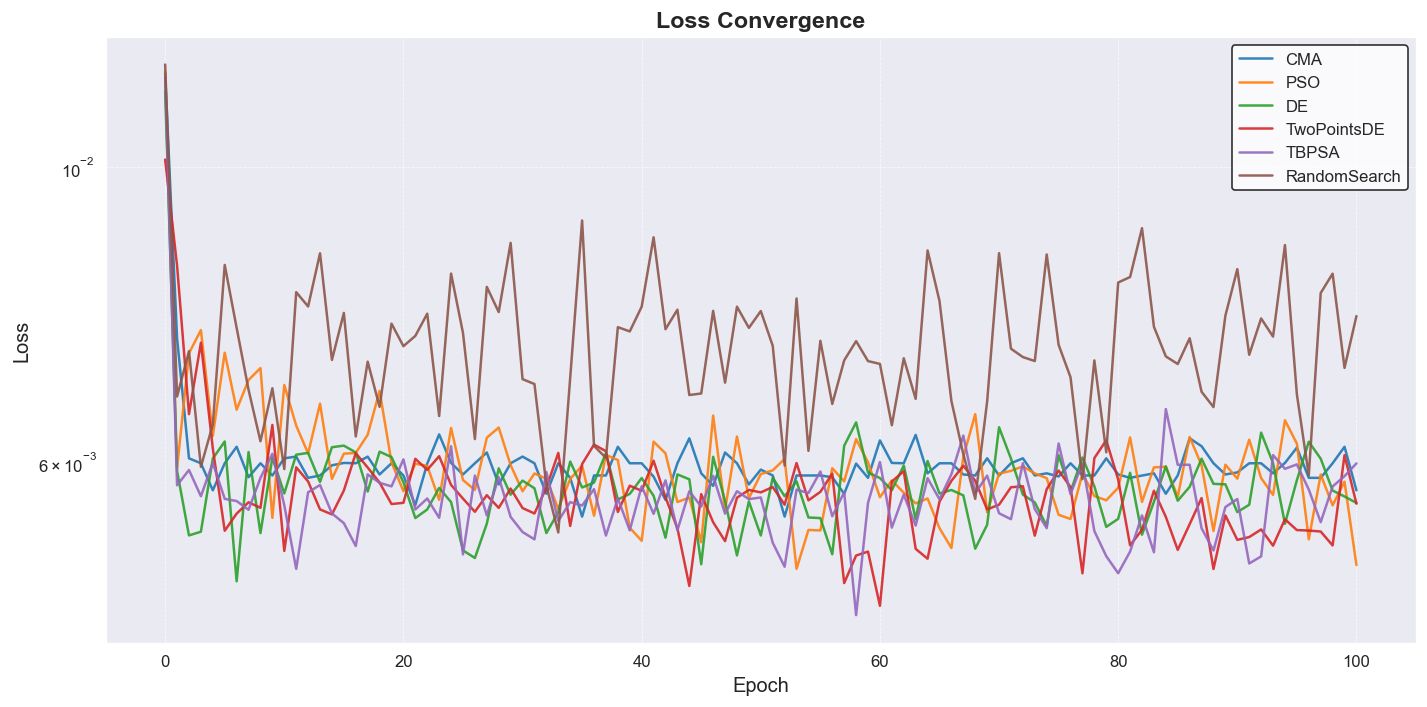

In [117]:

min_iterations = df[df["max_iterations"] == 100]

plt.figure(figsize=(12, 6), dpi=120)

for idx, row in min_iterations.iterrows():
    plt.semilogy(row['best_per_epoch'], label=f"{row['algorithm']}",linewidth=1.5,alpha=0.9)

plt.set_cmap('tab10')

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Loss Convergence", fontsize=14, fontweight='bold')


plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.legend(
    loc="upper right",
    fontsize=10,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)

plt.tight_layout()
plt.show()



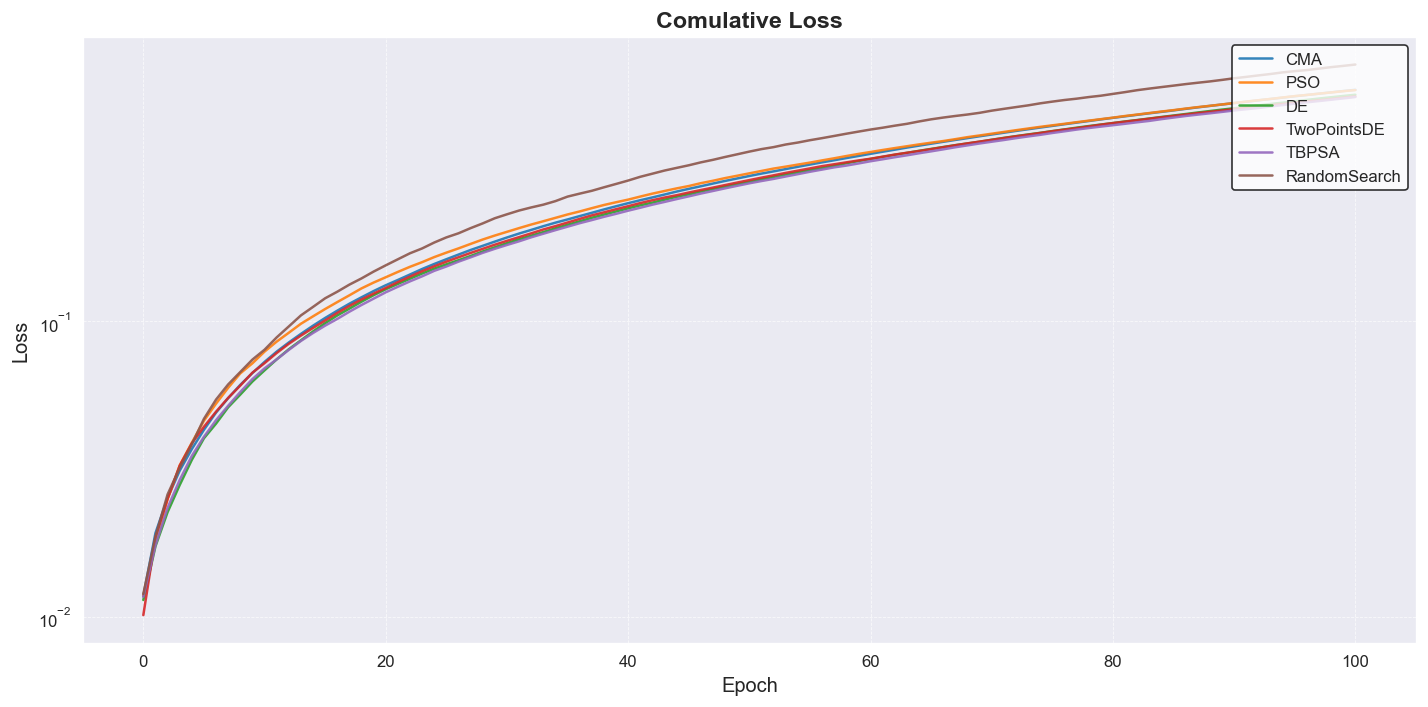

In [118]:
min_iterations = df[df["max_iterations"] == 100]

plt.figure(figsize=(12, 6), dpi=120)



for idx, row in min_iterations.iterrows():
    plt.semilogy(np.cumulative_sum(row['best_per_epoch']), label=f"{row['algorithm']}",linewidth=1.5,alpha=0.9)

plt.set_cmap('tab10')

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Comulative Loss", fontsize=14, fontweight='bold')


plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.legend(
    loc="upper right",
    fontsize=10,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)

plt.tight_layout()
plt.show()


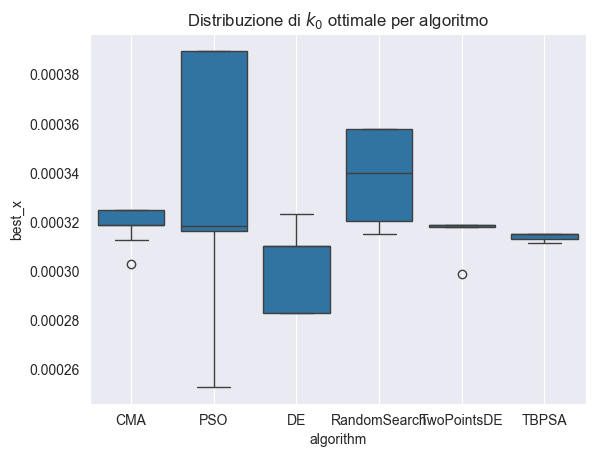

In [46]:
sns.boxplot(data=df, x="algorithm", y="best_x")
plt.title("Distribuzione di $k_0$ ottimale per algoritmo")
plt.grid()
plt.show()

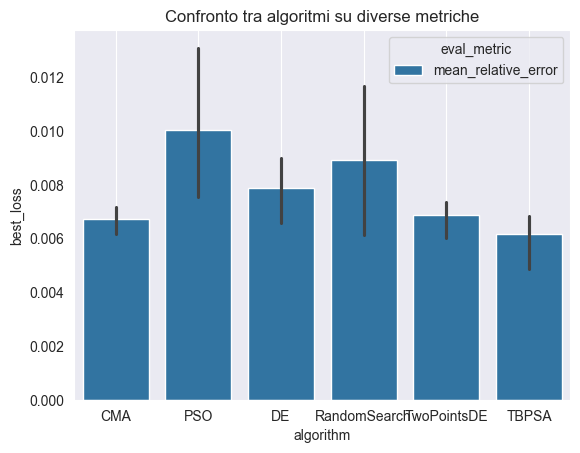

In [47]:
sns.barplot(data=df, x="algorithm", y="best_loss", hue="eval_metric")
plt.title("Confronto tra algoritmi su diverse metriche")
plt.grid()
plt.show()

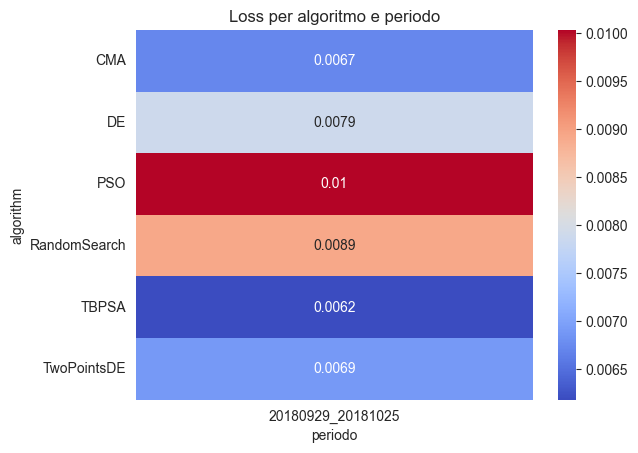

In [48]:
import re



df["periodo"] = df["experimental_data_path"].apply(lambda x: extract_period(x))  # definisci questa funzione

pivot = df.pivot_table(index="algorithm", columns="periodo", values="best_loss")
import seaborn as sns
sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Loss per algoritmo e periodo")
plt.show()

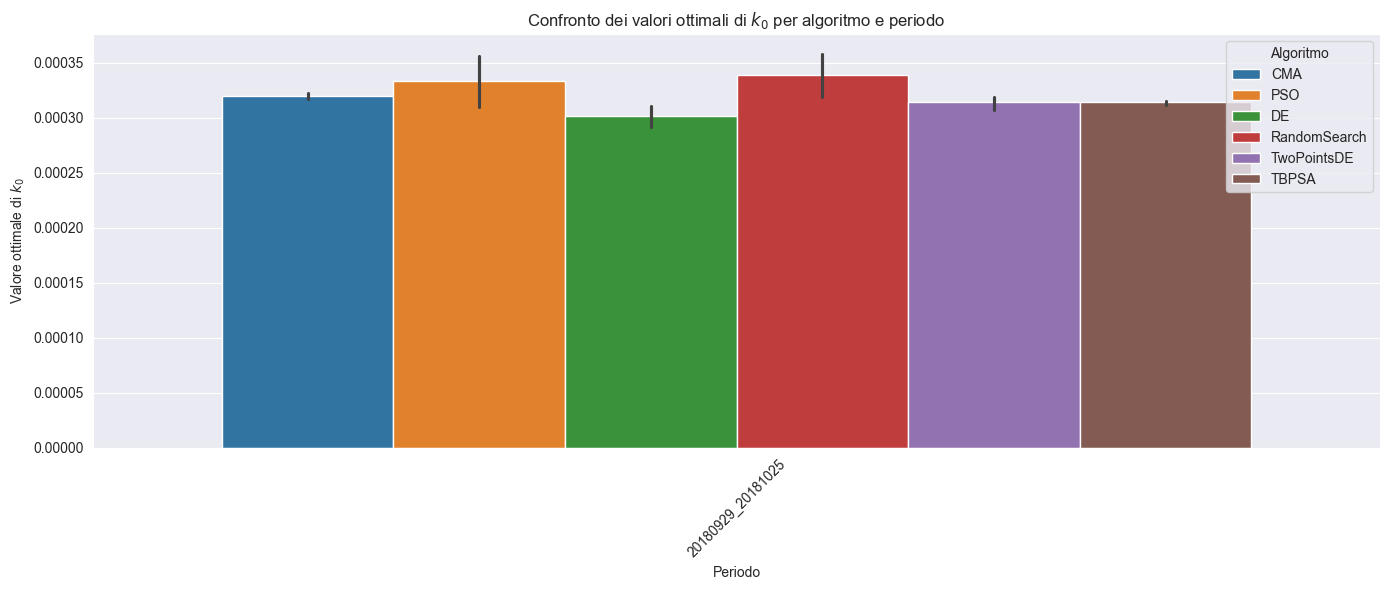

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

plot_k0_comparison(df)


### PLOT CONVERGENZA DEI PARAMETRI ###
Non ho la minima idea di come farlo